# Phase 1 Validation: `lagrangian.py`

Every notebook in this project shares one recipe: write `T` and `U` in
generalized coordinates, form the Lagrangian, derive and solve the
Euler-Lagrange equations, integrate numerically. `lagrangian.py` factors
that recipe out (`euler_lagrange`, `build_ode_system`, `linearize`,
`normal_mode_frequencies`) instead of every notebook hand-rolling it, as
the legacy versions in `legacy/` did.

This notebook validates the engine on the two systems with exact,
independent closed-form answers: the damped harmonic oscillator and the
2-mass/3-spring coupled oscillator.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import lagrangian as lg

## Single oscillator: undamped and damped

The legacy `Harmonic Oscillator.ipynb` solved the damped Newtonian ODE
`m*x_dd + b*x_d + k*x = 0` directly, skipping the Lagrangian entirely --
inconsistent with every other notebook in this project. Here it's derived
properly from `L = (T - U)`, and for damping, `L = (T - U)*exp(b*t)` (a
Caldirola-Kanai-style trick: multiplying the Lagrangian by `exp(b*t)`
before applying Euler-Lagrange). That trick is used again later in
`Coupled_Harmonic_Oscillator`'s legacy version but was never checked
against a known answer -- here it is.

In [2]:
t, m, k, b = sp.symbols('t m k b')
x = sp.Function('x')(t)
T = 0.5 * m * sp.diff(x, t)**2
U = 0.5 * k * x**2

# --- undamped ---
sols, coords_d, _ = lg.euler_lagrange(T - U, [x], t)
dSdt = lg.build_ode_system(sols, [x], coords_d, t, (m, k))

t_arr = np.linspace(0, 10, 2000)
m_val, k_val = 1.0, 1.0
x0, v0 = 1.0, 0.0
sol = lg.integrate(dSdt, [x0, v0], t_arr, (m_val, k_val))

w = np.sqrt(k_val / m_val)
x_exact = x0 * np.cos(w * t_arr)
err_undamped = np.max(np.abs(sol[:, 0] - x_exact))
print(f'undamped: max|x_num - x_exact| = {err_undamped:.2e}  (w = sqrt(k/m) = {w:.4f})')

# --- damped, via the exp(b*t) trick ---
sols_d, coords_d_d, coords_dd_d = lg.euler_lagrange((T - U) * sp.exp(b * t), [x], t)
print('Euler-Lagrange EOM (solved x_dd):', sols_d[coords_dd_d[0]])

dSdt_d = lg.build_ode_system(sols_d, [x], coords_d_d, t, (m, k, b))
b_val = 0.3
sol_d = lg.integrate(dSdt_d, [x0, v0], t_arr, (m_val, k_val, b_val))

w0 = np.sqrt(k_val / m_val)
beta = b_val / 2.0
wd = np.sqrt(w0**2 - beta**2)
phi = np.arctan(-beta / wd)
C = x0 / np.cos(phi)
x_exact_d = C * np.exp(-beta * t_arr) * np.cos(wd * t_arr + phi)
err_damped = np.max(np.abs(sol_d[:, 0] - x_exact_d))
print(f'damped:   max|x_num - x_exact| = {err_damped:.2e}  (w_d = {wd:.4f})')

undamped: max|x_num - x_exact| = 2.35e-07  (w = sqrt(k/m) = 1.0000)
Euler-Lagrange EOM (solved x_dd): -1.0*b*Derivative(x(t), t) - 1.0*k*x(t)/m
damped:   max|x_num - x_exact| = 8.11e-08  (w_d = 0.9887)


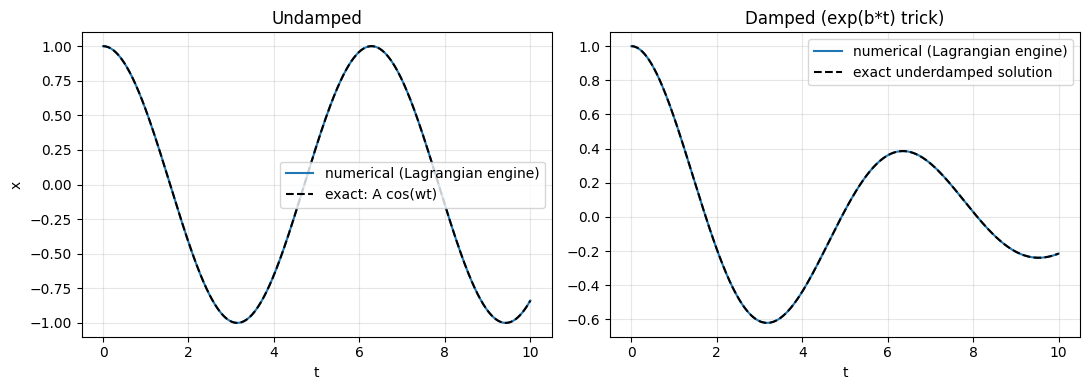

PASS: both undamped and damped single-oscillator cases match their closed-form solutions.
The exp(b*t)-Lagrangian damping trick genuinely reproduces standard linear damping, not just visually.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t_arr, sol[:, 0], label='numerical (Lagrangian engine)')
axes[0].plot(t_arr, x_exact, 'k--', label='exact: A cos(wt)')
axes[0].set_title('Undamped'); axes[0].set_xlabel('t'); axes[0].set_ylabel('x'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(t_arr, sol_d[:, 0], label='numerical (Lagrangian engine)')
axes[1].plot(t_arr, x_exact_d, 'k--', label='exact underdamped solution')
axes[1].set_title('Damped (exp(b*t) trick)'); axes[1].set_xlabel('t'); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/phase1_sho_validation.png', dpi=150, bbox_inches='tight')
plt.show()

assert err_undamped < 1e-4, f'undamped SHO error {err_undamped:.2e} too large'
assert err_damped < 1e-4, f'damped SHO error {err_damped:.2e} too large'
print('PASS: both undamped and damped single-oscillator cases match their closed-form solutions.')
print('The exp(b*t)-Lagrangian damping trick genuinely reproduces standard linear damping, not just visually.')

## Coupled oscillator: normal-mode frequencies

Two masses, three springs (`k1` to a wall, `k2` between the masses, `k2`
from the second mass to the opposite wall). `linearize()` gives the
mass/stiffness matrices straight from the same symbolic Lagrangian (no
separately hand-derived formula needed); its normal-mode frequencies are
checked two ways: against a direct-by-hand Hessian for this specific
symmetric case, and against the FFT of the actual nonlinear-integration
output at small amplitude (this system happens to be exactly linear, so
this is also an exact check, not just approximate).

In [4]:
m1, m2, k1, k2 = sp.symbols('m1 m2 k1 k2')
x1 = sp.Function('x1')(t)
x2 = sp.Function('x2')(t)
T2 = 0.5*m1*sp.diff(x1, t)**2 + 0.5*m2*sp.diff(x2, t)**2
U2 = 0.5*k1*x1**2 + 0.5*k2*(x1 - x2)**2 + 0.5*k2*x2**2
L2 = T2 - U2

M, K, coords_d2 = lg.linearize(L2, [x1, x2], t, equilibrium={x1: 0, x2: 0})
params = {m1: 1.0, m2: 1.0, k1: 1.0, k2: 1.0}
freqs = lg.normal_mode_frequencies(M, K, params)
print('normal_mode_frequencies():', freqs)

# hand Hessian for m1=m2=1, k1=k2=1
Mn = np.eye(2)
Kn = np.array([[2.0, -1.0], [-1.0, 2.0]])
freqs_hand = np.sort(np.sqrt(np.linalg.eigvals(np.linalg.solve(Mn, Kn)).real))
print('hand-derived Hessian:      ', freqs_hand)

sols2, cd2, _ = lg.euler_lagrange(L2, [x1, x2], t)
dSdt2 = lg.build_ode_system(sols2, [x1, x2], cd2, t, (m1, m2, k1, k2))
t_arr2 = np.linspace(0, 200, 20000)
sol2 = lg.integrate(dSdt2, [0.01, 0, -0.01, 0], t_arr2, (1.0, 1.0, 1.0, 1.0))

dt = t_arr2[1] - t_arr2[0]
spec = np.abs(np.fft.rfft(sol2[:, 0] - sol2[:, 0].mean()))
fr = 2 * np.pi * np.fft.rfftfreq(len(t_arr2), d=dt)
peak_w = fr[np.argmax(spec)]
print(f'FFT dominant angular frequency from full simulation: {peak_w:.4f}')

normal_mode_frequencies(): [1.         1.73205081]
hand-derived Hessian:       [1.         1.73205081]
FFT dominant angular frequency from full simulation: 1.7278


In [5]:
err_freq = np.max(np.abs(freqs - freqs_hand))
err_fft = min(abs(peak_w - f) for f in freqs)
print(f'max|linearize freqs - hand Hessian| = {err_freq:.2e}')
print(f'|FFT peak - nearest normal mode|    = {err_fft:.4f}')
assert err_freq < 1e-8, 'linearize() normal modes disagree with the hand-derived Hessian'
assert err_fft < 0.05, 'FFT peak frequency does not match either normal mode closely enough'
print('PASS: linearize()/normal_mode_frequencies() match both an independent hand derivation')
print('and the frequency actually seen in the full numerical integration.')

max|linearize freqs - hand Hessian| = 0.00e+00
|FFT peak - nearest normal mode|    = 0.0043
PASS: linearize()/normal_mode_frequencies() match both an independent hand derivation
and the frequency actually seen in the full numerical integration.
